###### Carleton School of Information Technology
### ITEC 5920 – Applied Deep Learning
### Winter 2026
### Instructor: Dr. Marzieh Amini
### Prepared by: Aziz Al-Najjar


Sources: 

https://pub.towardsai.net/decision-trees-in-machine-learning-ml-with-python-tutorial-3bfb457bce67#f6f6

https://towardsai.net/p/l/hands-on-random-forest-with-python

https://pub.towardsai.net/all-about-adaboost-ba232b5521e9

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html


This tutorial provides an introduction to the basic concepts and usage of Decision Trees, AdaBoost, and Random Forest using the scikit-learn library in Python. These algorithms are commonly used for classification and regression tasks, and are known for their interpretability, robustness, and high accuracy. The tutorial covers the following topics:

* The theory behind Decision Trees and how they are used for classification
* How to train, evaluate, and visualize Decision Trees using the scikit-learn library.
* An overview of the AdaBoost algorithm 
* How to train, evaluate, and visualize AdaBoost using the scikit-learn library.
* An overview of the Random Forest algorithm
* How to train, evaluate, and visualize Random Forest using the scikit-learn library.

The tutorial includes code examples and visualizations to help you understand the concepts and usage of these algorithms. The breast_cancer dataset is used throughout the tutorial as an example. By the end of the tutorial, you will have a solid understanding of how to use Decision Trees, AdaBoost, and Random Forest in your own projects.

#Dataset 

In this tutorial, we will use The breast cancer dataset. It is a well-known dataset that is often used to demonstrate machine learning algorithms. The dataset contains information about breast cancer tumors, including various measurements taken from the tumors such as radius, texture, perimeter, and smoothness. Each tumor is labeled as either benign (non-cancerous) or malignant (cancerous) based on a biopsy.

### Import the necessary libraries

Import the necessary libraries, including matplotlib for plotting, and the load_breast_cancer function from sklearn.datasets to load the breast_cancer dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

Start by loading the breast_cancer dataset, store the feature variables (X) and target variable (y) in separate variables. 

In [2]:
# Load the breast_cancer dataset
breast_cancer = datasets.load_breast_cancer()
X, y = breast_cancer.data, breast_cancer.target
print("Feature names:", breast_cancer.feature_names)
print("Target names:", breast_cancer.target_names)
print("X shape: ", X.shape)
print("y shape: ", y.shape)


Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target names: ['malignant' 'benign']
X shape:  (569, 30)
y shape:  (569,)


Splitting it into training and test sets

In [3]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print("X_train shape:", X_train.shape)
print("y_train shape", y_train.shape)
print("X_test shape", X_test.shape)
print("y_test shape", y_test.shape)


X_train shape: (455, 30)
y_train shape (455,)
X_test shape (114, 30)
y_test shape (114,)


Keep in mind that the breast_cancer dataset is a relatively small and simple dataset, in real-world scenarios, you might have to deal with much larger and more complex datasets. In such cases, you might need to consider additional techniques such as feature scaling, dimensionality reduction, and ensemble methods to improve the performance of your models.

After loading the dataset, lets start working with our models

# Decsion Trees:

Decision trees are a popular and interpretable machine learning model that can be used for both classification and regression tasks. The basic idea behind decision trees is to recursively split the data into subsets based on the values of the input features. The goal is to create subsets that are as pure as possible, i.e. that contain only samples from a single class. The final result is a tree-like model that can be used to make predictions.

Start by loading the DecisionTreeClassifier from sklearn.tree

In [4]:
from sklearn.tree import DecisionTreeClassifier

Create an instance of the DecisionTreeClassifier class and fit it to the data using the fit method. The random_state parameter is set to 0 to ensure reproducibility.

In [5]:
# Create and train a Decision Tree classifier
DT = DecisionTreeClassifier(max_depth=3, random_state=0)
DT.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

Now that the model is trained, we can use it to make predictions on the test set and evaluate its performance.

In [6]:
from sklearn import metrics

# Evaluate the classifier on the test set
y_pred = DT.predict(X_test)
accuracy = metrics.accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy: {:.2f}%".format(accuracy*100))

Decision Tree Accuracy: 96.49%


#### Visualize the Decision Tree
We can also visualize the Decision Tree by using the plot_tree function from sklearn.tree to generate a graphical representation of the tree. This will give you a better understanding of how the Decision Tree splits the data based on the features and how the final tree structure looks like.

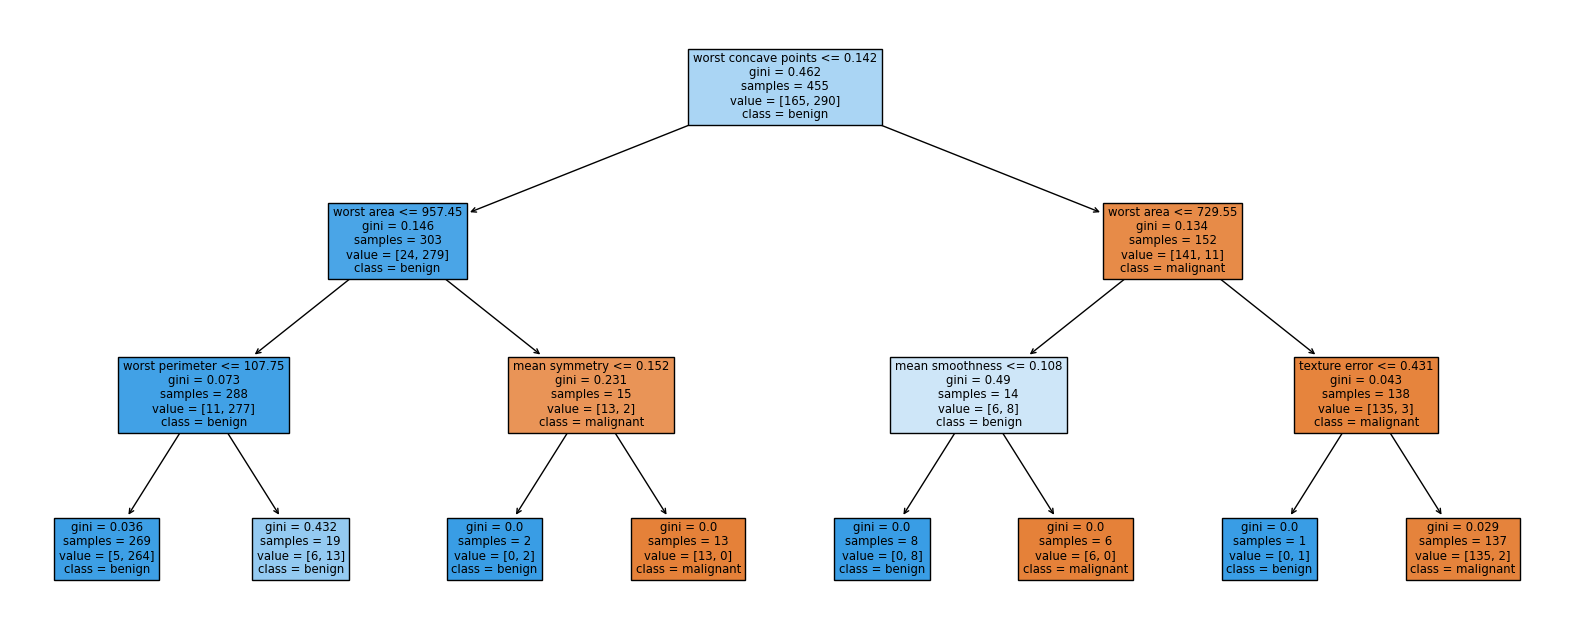

In [7]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,8))
plot_tree(DT, feature_names=breast_cancer.feature_names, class_names=breast_cancer.target_names, filled=True)
plt.show()

You can also play around with the parameters of the DecisionTreeClassifier such as max_depth, min_samples_split, criterion etc. to see how they affect the tree structure and the accuracy of the model.

## Adaboost

Adaboost (Adaptive Boosting) is an ensemble learning algorithm that can be used for both classification and regression problems. It works by combining multiple weak learners (base estimators) in order to improve the overall performance of the model.

In Adaboost, the base estimator is trained multiple times on different subsets of the data. At each iteration, the weights of the incorrectly classified samples are increased, so that the next base estimator focuses more on the samples that are difficult to classify. The final predictions are made by combining the predictions of all the base estimators, with more weight given to the estimators that performed well on the training data.

Start by loading the AdaBoostClassifier from the sklearn.ensemble and creating an instance of the AdaBoostClassifier class with DecisionTreeClassifier as the base estimator

In [8]:
from sklearn.ensemble import AdaBoostClassifier

DT = DecisionTreeClassifier(max_depth=3, random_state=0)
clf = AdaBoostClassifier(base_estimator=DT, n_estimators=100, random_state=0)

here, we will use decision tree as the base estimator for the Adaboost model since it is a simple yet powerful algorithm that can handle both categorical and numerical data. It also has the ability to handle missing values and outliers, which makes it a robust choice for the base estimator. 

Next step is to fit the training data using the .fit method and evaluate the model using the predict and accuracy_score functions

In [9]:
# Fit the classifier to the training data
clf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = clf.predict(X_test)

# Compute the accuracy of the classifier
acc = metrics.accuracy_score(y_test, y_pred)
print("AdaBoost Accuracy: {:.2f}%".format(acc * 100))

AdaBoost Accuracy: 94.74%


As we can see, adaboost was able to increase the classification accuracy compared to a single decsion tree.  

## Random Forest

Random forests are an ensemble of decision trees that work together to improve performance. The basic idea behind random forests is to train multiple decision trees on different subsets of the data and then average their predictions. By training multiple decision trees on different subsets of the data, random forests are able to reduce overfitting and improve performance

Start by loading the RandomForestClassifier from the sklearn.ensemble and creating an instance of the RandomForestClassifier class 

In [10]:
# Create and train a Random Forest classifier

from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators= 300,random_state=0)


Next step is to fit the training data using the .fit method and evaluate the model using the predict and accuracy_score functions

In [11]:
# Fit the classifier to the training data
clf.fit(X_train, y_train)

# Make predictions on the test data
y_pred = clf.predict(X_test)

# Compute the accuracy of the classifier
acc = metrics.accuracy_score(y_test, y_pred)
print("RF Accuracy: {:.2f}%".format(acc * 100))

RF Accuracy: 98.25%


With the correct number of estimators, Random Forest is able to improve the classification results even further 